# Assignment 2: AI-Assisted Data Cleaning & Fraud Detection

You can run this notebook in Google Colab or Jupyter Notebook.  
Please **read each instruction carefully** and complete each task step by step.

---

## Background

Online payment fraud is one of the most significant challenges facing the financial industry today. Every year, billions of dollars are lost to fraudulent transactions, making accurate and scalable fraud detection systems critically important.

This assignment is based on the **IEEE-CIS Fraud Detection** dataset, originally published as a Kaggle competition by the **IEEE Computational Intelligence Society (IEEE-CIS)** in collaboration with **Vesta Corporation**, a leading payment service company. The dataset contains real-world anonymized e-commerce transaction records, and the task is to predict whether a given transaction is fraudulent.

---

## Learning Goals

By working through this notebook, you will:

- Use a **Large Language Model (LLM)** to semantically understand and clean structured data.
- Translate LLM-generated cleaning logic into **executable Python/Pandas code**.
- Apply **two machine learning methods** to a real-world binary classification problem.
- Evaluate model performance using appropriate metrics for **imbalanced datasets**.

---

## Dataset Overview

This assignment uses the following data files:

### Task 1 — Raw Data (for LLM Cleaning)

| File | Rows | Description |
|------|------|-------------|
| `train_transaction.csv` | ~590,000 | Core transaction records with labels |
| `train_identity.csv` | ~144,000 | Identity information linked to transactions |

> **Note:** Not every transaction has a corresponding identity record. The join is a **left join** on `TransactionID`. In Task 1, you will only work with the **first 50 rows** of these files.

### Task 2 — Pre-processed Data (for Model Training)

| File | Rows | Description |
|------|------|-------------|
| `training_data.csv` | ~472,000 | Fully pre-processed training set (merged + cleaned) |
| `test_data.csv` | ~118,000 | Fully pre-processed test set (no labels) |
| `sample_submission.csv` | ~118,000 | Template for your prediction submission |

---

## Data Dictionary

### Transaction Table (~394 columns)

| Column(s) | Type | Description |
|-----------|------|-------------|
| `TransactionID` | int | Unique identifier for each transaction |
| `isFraud` | int (0/1) | **Target variable** — 1 = fraudulent, 0 = legitimate *(train only)* |
| `TransactionDT` | int | Timedelta (in seconds) from a reference point, **not** an actual timestamp |
| `TransactionAmt` | float | Transaction amount in USD |
| `ProductCD` | str | Product code: W, H, C, S, or R |
| `card1`–`card6` | int/str | Payment card information (type, bank, country, etc.) |
| `addr1`, `addr2` | int | Billing address (region, country) |
| `dist1`, `dist2` | float | Distance between addresses |
| `P_emaildomain` | str | Purchaser's email domain (e.g., gmail.com) |
| `R_emaildomain` | str | Recipient's email domain |
| `C1`–`C14` | float | Anonymized count features (e.g., number of addresses linked to a card) |
| `D1`–`D15` | float | Anonymized timedelta features (e.g., days since last transaction) |
| `M1`–`M9` | str (T/F) | Match features (e.g., whether name on card matches address) |
| `V1`–`V339` | float | Anonymized Vesta engineered features |

### Identity Table (~41 columns)

| Column(s) | Type | Description |
|-----------|------|-------------|
| `TransactionID` | int | Foreign key linking to the transaction table |
| `id_01`–`id_38` | int/str | Anonymized identity features (device, network, etc.) |
| `DeviceType` | str | `mobile` or `desktop` |
| `DeviceInfo` | str | Device model/OS string (e.g., `Windows`, `iOS 11.3`) |

---

## A Note on Class Imbalance

In this dataset, only about **3.5% of transactions are fraudulent**. This means a naive model that predicts "not fraud" for every transaction would achieve ~96.5% accuracy — but would be completely useless in practice.

For this reason, you should **not** use accuracy as your primary evaluation metric. Instead, use **AUC-ROC (Area Under the ROC Curve)**, recall and F1-score, which measures a model's ability to distinguish between the two classes regardless of the class distribution.

**Do remember, even your model marks a false fraud, the card holder can use OTP (one time password) by SMS to approve this transcation. But if you miss a true fraud, bank will lose real money.**

---

## Assignment Structure

| Task | Description |
|------|-------------|
| **Task 1.1** | Use an LLM to semantically clean and standardize selected columns from 50 rows of data |
| **Task 1.2** | With AI assistance, write a Python function that applies the same cleaning logic to the full dataset |
| **Task 2** | Train and evaluate two machine learning models on the pre-cleaned full dataset |

## You should deliver:

- This Notebook itself
- `Task1_deliver.csv`, generated by this Notebook
- `Task2_deliver.csv`, generated by this Notebook

## Special Note

You may need to use API key to leverage LLM. Your unique API key should be sent by Mr.LIU Muyun via email. If you haven't received it, please mail him (muyunliu@cuhk.edu.hk) to get it.

Those keys are properties of CUHK. **Please DONNOT leak the API key to anyone else.** 

## Preparation of libraries: Please run the following cell directly.

In [1]:
# ── Standard Library ──────────────────────────────────────────────
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Machine Learning ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# Add or remove models above depending on your choice in Task 2

# ── LLM API (Task 1.1 & 1.2) ─────────────────────────────────────
from openai import OpenAI

print('All packages loaded successfully.')

All packages loaded successfully.


---

## Task 1.1 — LLM-Assisted Semantic Data Cleaning

### Overview

Traditional data cleaning relies on manually written rules: replace missing values with the mean, drop outliers beyond 3 standard deviations, encode categories with a fixed mapping, and so on. These rules are effective, but they require the programmer to already understand the data.

**Large Language Models offer a different approach.** Because LLMs have been trained on vast amounts of text — including documentation, research papers, and domain knowledge — they can *reason about the meaning* of a column, not just its statistics. Given a column named `P_emaildomain` containing values like `gmail.com`, `googlemail.com`, and `gmai.com`, an LLM can recognize that the first two are the same provider and the third is likely a typo, and suggest a normalization strategy accordingly.

In this task, you will act as a **data analyst working with an LLM as your assistant**. Your goal is not to write cleaning code yet — it is to use the LLM to *understand* the data and *decide* what cleaning is needed.

---

### Columns to Clean

You will work with the following **6 columns** from `train_transaction.csv`. These columns were selected because they contain human-readable, semantically meaningful values that an LLM can reason about:

| Column | Example Values | Potential Issues |
|--------|---------------|-----------------|
| `ProductCD` | `W`, `H`, `C`, `S`, `R` | What do these codes mean? Are there invalid values? |
| `card4` | `visa`, `mastercard`, `american express` | Inconsistent capitalization, abbreviations |
| `card6` | `debit`, `credit`, `debit or credit` | Ambiguous categories, needs standardization |
| `P_emaildomain` | `gmail.com`, `googlemail.com`, `gmai.com` | Typos, aliases for the same provider |
| `M1`–`M9` | `T`, `F`, `NaN` | What do T/F mean in this context? How to handle missing values? |
| `DeviceInfo` | `Windows`, `iOS 11.3.0`, `SM-G935F Build/MMB29K` | Noisy strings, needs brand/OS extraction |

---

**Step 1 — Load the first 50 rows**

Load the first 50 rows of `train_transaction.csv` and extract the 6 columns listed above.

In [2]:
target_cols_trans = ['TransactionID', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1']
target_cols_ident = ['TransactionID', 'DeviceInfo']

df_trans = pd.read_csv('train_transaction.csv', usecols=target_cols_trans, nrows=50)
df_ident = pd.read_csv('train_identity.csv', usecols=target_cols_ident)

df_sample = df_trans.merge(df_ident, on='TransactionID', how='left')

df_sample.head(10)
df_sample.info()


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionID  50 non-null     int64
 1   ProductCD      50 non-null     str  
 2   card4          50 non-null     str  
 3   card6          50 non-null     str  
 4   P_emaildomain  46 non-null     str  
 5   M1             19 non-null     str  
 6   DeviceInfo     8 non-null      str  
dtypes: int64(1), str(6)
memory usage: 2.9 KB


**Step 2 — Explore the Data**

Before constructing your prompt, explore the 6 target columns to understand their unique values and missing counts. This will help you write a more precise prompt in Step 3.

In [3]:
# Preview unique values and missing counts for each target column
for col in ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'DeviceInfo']:
    unique_vals = df_sample[col].dropna().unique().tolist()
    missing = df_sample[col].isna().sum()
    print(f"[{col}]  missing: {missing}/50  unique values: {unique_vals}\n")

[ProductCD]  missing: 0/50  unique values: ['W', 'H', 'C', 'S']

[card4]  missing: 0/50  unique values: ['discover', 'mastercard', 'visa', 'american express']

[card6]  missing: 0/50  unique values: ['credit', 'debit']

[P_emaildomain]  missing: 4/50  unique values: ['gmail.com', 'outlook.com', 'yahoo.com', 'mail.com', 'anonymous.com', 'hotmail.com', 'verizon.net', 'aol.com', 'me.com']

[M1]  missing: 31/50  unique values: ['T']

[DeviceInfo]  missing: 42/50  unique values: ['SAMSUNG SM-G892A Build/NRD90M', 'iOS Device', 'Windows', 'MacOS']



**Step 3 — Ask the LLM to Clean the Data and Save the Result**

Now you will send both the column descriptions **and the raw 50-row data** to the LLM, and ask it to return the cleaned data directly in JSON format.

Your code should:
1. Construct a prompt that includes the raw data and asks the LLM to clean and return it as structured JSON
2. Call the API and parse the JSON response
3. Save the result as `Task1_deliver.csv`

> 💡 **Tip:** Ask the LLM to return a JSON array where each element is a cleaned row. Specify exactly what cleaning you expect for each column (e.g. normalize email aliases, extract device category, encode M1 as 0/1/-1).

Your deliverables for this task are:
1. The prompt you used
2. The saved `Task1_deliver.csv` file

In [4]:
API_KEY = "sk-cJvvaaDosK2UQKWvPeyK7HyrRK004ul6L9IN7YdZm00cd7xT"


# The part is the API key calling.
# DONNOT change this part by yourself.
client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.bianxie.ai/v1"
)

raw_data_json = df_sample.drop(columns=['TransactionID']).to_json(orient='records', indent=2)
# Pre-written part ends.

# You should start from here

prompt_clean = f"""
You are a data cleaning expert. Below is a sample of 50 rows from an e-commerce fraud detection dataset.

## Columns
- ProductCD: product category code (W/H/C/S/R)
- card4: card network (e.g. visa, mastercard) — normalize to lowercase
- card6: card type (debit/credit) — normalize to lowercase, map "debit or credit" to "unknown"
- P_emaildomain: purchaser email domain — normalize aliases (e.g. googlemail.com → gmail.com, ymail.com → yahoo.com, outlook.com/live.com/hotmail.com → microsoft.com), fill missing with "unknown"
- M1: match flag (T/F) — encode as 1/0, fill missing with -1
- DeviceInfo: raw device string — extract one of: windows / ios / android / mac / linux / other / unknown

## Raw Data
{raw_data_json}

## Instructions
Return ONLY a valid JSON array of 50 objects, one per row, with the 6 cleaned columns above.
Do not include any explanation or extra text. Example format:
[
  {{"ProductCD": "W", "card4": "visa", "card6": "debit", "P_emaildomain": "gmail.com", "M1": 1, "DeviceInfo": "windows"}},
  ...
]
"""

# Your part ends here.

# DONNOT change the following part.
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a data cleaning expert. Return only valid JSON, no explanation."},
        {"role": "user", "content": prompt_clean}
    ],
    temperature=0.0,
    max_tokens=4096
)

raw_output = response.choices[0].message.content

cleaned_data = json.loads(raw_output)
df_deliver = pd.DataFrame(cleaned_data)
df_deliver.to_csv('Task1_deliver.csv', index=False)

print("Saved Task1_deliver.csv")
print(df_deliver.head(10))

Saved Task1_deliver.csv
  ProductCD       card4   card6  P_emaildomain  M1 DeviceInfo
0         W    discover  credit        unknown   1    unknown
1         W  mastercard  credit      gmail.com  -1    unknown
2         W        visa   debit  microsoft.com   1    unknown
3         W  mastercard   debit      yahoo.com  -1    unknown
4         H  mastercard  credit      gmail.com  -1    unknown
5         W        visa   debit      gmail.com   1    unknown
6         W        visa   debit      yahoo.com   1    unknown
7         W        visa   debit        unknown  -1    unknown
8         H        visa   debit        unknown  -1        ios
9         W  mastercard   debit      yahoo.com   1    unknown


---

## Task 1.2 — AI-Assisted Code Generation for Full-Scale Cleaning

### Overview

In Task 1.1, you used an LLM to directly process a small sample of data row by row. However, this approach does not scale — a real dataset with hundreds of thousands of rows cannot fit into a single prompt.

The practical workflow is different: instead of asking the LLM to *process* the data, you ask it to *write the code* that processes the data. You then review and refine the generated code to ensure it correctly captures your cleaning logic.

In this task, you will use an LLM to generate a Python cleaning function based on the same logic you applied in Task 1.1.

> **Note:** You do **not** need to run any code in this task. Write your prompt and paste the generated function as instructed. Your submission will be reviewed for logical correctness and consistency with your Task 1.1 decisions.

---


**Step 1 — Construct a prompt asking the LLM to write a cleaning function**

Your prompt should:
- Describe each of the 6 columns and their cleaning requirements
- Be consistent with the cleaning decisions you made in Task 1.1
- Ask the LLM to write a single Python function `clean_dataframe(df)` that accepts a raw DataFrame and returns a cleaned copy

Paste your prompt in the markdown cell below.

**My Prompt (Deliverable 1):**

*(Paste your prompt here)*

**Step 2 — Paste and review the generated function**

Copy the LLM's output into the code cell below. Read through the logic carefully:
- Does it correctly handle missing values?
- Is it consistent with what you did in Task 1.1?
- Are there any errors or missing steps?

Make any corrections you think are necessary directly in the code cell.

In [ ]:
# Paste the codes you asked AI to generate.

def clean_dataframe(df):
    df = df.copy()

    # card4 — normalize to lowercase
    df['card4'] = df['card4'].str.strip().str.lower().fillna('unknown')

    # card6 — normalize and map ambiguous value
    df['card6'] = df['card6'].str.strip().str.lower()
    df['card6'] = df['card6'].replace('debit or credit', 'unknown').fillna('unknown')

    # P_emaildomain — normalize aliases and fill missing
    email_alias_map = {
        'googlemail.com': 'gmail.com',
        'ymail.com':      'yahoo.com',
        'hotmail.com':    'microsoft.com',
        'outlook.com':    'microsoft.com',
        'live.com':       'microsoft.com',
    }
    df['P_emaildomain'] = (
        df['P_emaildomain']
        .str.strip().str.lower()
        .replace(email_alias_map)
        .fillna('unknown')
    )

    # M1 — encode T→1, F→0, missing→-1
    df['M1'] = df['M1'].map({'T': 1, 'F': 0}).fillna(-1).astype(int)

    # DeviceInfo — extract broad device category from raw string
    def extract_device(val):
        if pd.isna(val):
            return 'unknown'
        val = str(val).lower()
        if 'windows' in val:
            return 'windows'
        elif 'ios' in val or 'iphone' in val or 'ipad' in val:
            return 'ios'
        elif 'android' in val or 'samsung' in val or 'sm-' in val:
            return 'android'
        elif 'mac' in val:
            return 'mac'
        elif 'linux' in val:
            return 'linux'
        else:
            return 'other'

    df['DeviceInfo'] = df['DeviceInfo'].apply(extract_device)

    return df

---

## Task 2 — Machine Learning for Fraud Detection

### Overview

With the data now cleaned and standardized, you are ready to build predictive models. In this task, you will train **two machine learning classifiers** on the full training dataset and evaluate their ability to detect fraudulent transactions.

Fraud detection is a classic **binary classification** problem, but with a critical challenge: the dataset is highly **imbalanced** — only about 3.5% of transactions are fraudulent. This means that standard accuracy is a misleading metric. A model that blindly predicts "not fraud" for every transaction would achieve over 96% accuracy while catching zero fraud cases.

To address this, you will evaluate your models using **AUC-ROC** and **F1-score**, which are robust to class imbalance and better reflect real-world utility.


### Part 1 — Model Training
Load `training_data.csv`, inspect it, then train a classifier to predict `isFraud`.
Your deliverables for Part 1:
- A trained model
- AUC-ROC and F1-score on a held-out validation split
- A ROC curve and confusion matrix


In [5]:
df_train = pd.read_csv('training_data.csv')

print(f"Shape: {df_train.shape}")
print(f"Fraud rate: {df_train['isFraud'].mean():.4f}")
print(f"\nColumn types:\n{df_train.dtypes.value_counts()}")
print(f"\nMissing values: {df_train.isnull().sum().sum()}")
df_train.head(3)

Shape: (472432, 434)
Fraud rate: 0.0350

Column types:
float64    399
str         22
int64       13
Name: count, dtype: int64

Missing values: 0


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3027809,0,1008491,100.00,R,6177,399.0,150.0,american express,150.0,...,ie 11.0 for desktop,24.0,1920x1080,match_status:2,T,F,T,T,desktop,other
1,3272886,0,7008212,29.99,W,7900,345.0,150.0,mastercard,224.0,...,unknown,-999.0,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown
2,3091256,0,2071522,107.95,W,11690,111.0,150.0,visa,226.0,...,unknown,-999.0,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown


[0]	validation_0-auc:0.84439
[100]	validation_0-auc:0.91171
[200]	validation_0-auc:0.92793
[299]	validation_0-auc:0.93615

Validation AUC-ROC : 0.9362
Validation F1-score: 0.5614

              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98     91181
       Fraud       0.47      0.70      0.56      3306

    accuracy                           0.96     94487
   macro avg       0.73      0.83      0.77     94487
weighted avg       0.97      0.96      0.97     94487



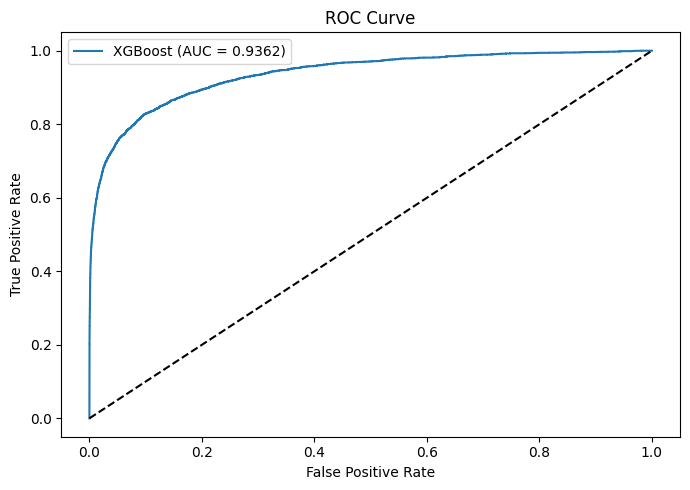

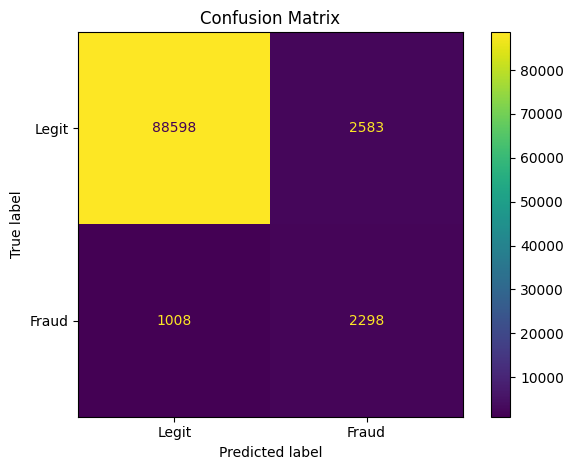

In [6]:
from xgboost import XGBClassifier

# ── Prepare features and target ───────────────────────────────────
drop_cols = ['TransactionID', 'isFraud']
X = df_train.drop(columns=drop_cols)
y = df_train['isFraud']

# Encode any remaining string columns
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# ── Train / validation split ──────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Train XGBoost ─────────────────────────────────────────────────
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=fraud_ratio,   # handles class imbalance
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# ── Evaluate ──────────────────────────────────────────────────────
y_prob = model.predict_proba(X_val)[:, 1]
y_pred = (y_prob >= 0.7).astype(int)

auc  = roc_auc_score(y_val, y_prob)
f1   = f1_score(y_val, y_pred)
print(f"\nValidation AUC-ROC : {auc:.4f}")
print(f"Validation F1-score: {f1:.4f}")
print(f"\n{classification_report(y_val, y_pred, target_names=['Legit', 'Fraud'])}")

# ── ROC Curve ─────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, display_labels=['Legit', 'Fraud'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

---

### Part 2 — Prediction on Test Set

Load `test_data.csv`, apply the same preprocessing, and generate fraud probability predictions for each transaction.

Submit your predictions as a CSV file named `Task2_deliver.csv` following the format of `sample_submission.csv`:

| Column | Description |
|--------|-------------|
| `TransactionID` | Transaction identifier |
| `isFraud` | Predicted fraud probability (float between 0 and 1) |

In [7]:
df_test = pd.read_csv('test_data.csv')

print(f"Test shape: {df_test.shape}")

# ── Align test features with training features ────────────────────
X_test = df_test.drop(columns=['TransactionID'])

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))

# Ensure column order matches training
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# ── Predict ───────────────────────────────────────────────────────
test_prob = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_prob
})
submission.to_csv('Task2_deliver.csv', index=False)

print("Saved Task2_deliver.csv")
submission.head(10)

Test shape: (118108, 433)
Saved Task2_deliver.csv


,TransactionID,isFraud
0,3303078,0.048162
1,3103888,0.183195
2,3397211,0.113423
3,3238027,0.079243
4,3178265,0.052090
5,3004694,0.250842
6,3418807,0.105220
7,3355899,0.041819
8,3377704,0.071875
9,3127623,0.113113


**End of the assignment 2**